In [221]:
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import os
import json

In [222]:
df = pd.read_csv('dataset.csv')

In [223]:
df.drop_duplicates(inplace=True)

In [224]:
df.shape[1]

11

In [225]:
# Print the percentage missing for each column

for col in df.columns:
    missing_percentage = df[col].isnull().mean() * 100
    print(f"{col}: {missing_percentage:.2f}% missing")

Engine: 1.14% missing
No. of Cylinders: 1.14% missing
Valves Per Cylinder: 1.14% missing
Valve Configuration: 42.83% missing
Fuel Supply System: 32.26% missing
Fuel Type: 0.09% missing
Engine Type: 4.55% missing
Emission Norm Compliance: 8.39% missing
Drive Type: 14.60% missing
Transmission: 0.09% missing
Power: 4.28% missing


In [226]:
def handle_missing_values(df, col):
    missing_pct = df[col].isnull().mean() * 100
    print(f"{col}: {missing_pct:.2f}% missing", end=" → ")

    # Drop if more than 50% missing
    if missing_pct > 50:
        df.drop(columns=[col], inplace=True)
        print("❌ Dropped column (>50% missing)")

    # Between 20% and 50% — fill with median/mode, no indicator
    elif missing_pct > 20:
        if df[col].dtype == 'object':
            fill_val = df[col].mode()[0]
            strategy = f"mode ({fill_val})"
        else:
            fill_val = df[col].median()
            strategy = f"median ({fill_val:.2f})"

        df[col].fillna(fill_val, inplace=True)
        print(f"🟠 Filled with {strategy} (20-50% missing)")

    # Between 10% and 20% — fill with mean/mode
    elif missing_pct > 10:
        if df[col].dtype == 'object':
            fill_val = df[col].mode()[0]
            strategy = f"mode ({fill_val})"
        else:
            fill_val = df[col].mean()
            strategy = f"mean ({fill_val:.2f})"

        df[col].fillna(fill_val, inplace=True)
        print(f"⚠️ Filled with {strategy} (10-20% missing)")

    # Less than 10% — use interpolation for numeric, mode for categorical
    elif missing_pct > 0:
        if df[col].dtype == 'object':
            fill_val = df[col].mode()[0]
            df[col].fillna(fill_val, inplace=True)
            print(f"✅ Filled with mode ({fill_val}) (<10% missing)")
        else:
            df[col].interpolate(method='linear', inplace=True)
            df[col].fillna(df[col].median(), inplace=True)  # catch any edge NaNs
            print(f"✅ Interpolated (<10% missing)")

    else:
        print("✅ No missing values")

    return df

In [227]:
def one_hot_encode_with_info(df, column_name, prefix=None):
    
    if prefix is None:
        prefix = column_name

    # get categories
    categories = sorted(df[column_name].dropna().unique())

    print(f"\nFeature: {column_name}")
    print("All Categories:", categories)

    dropped_category = categories[0]
    print("Dropped Category:", dropped_category)

    # create dummies
    dummies = pd.get_dummies(
        df[column_name],
        prefix=prefix,
        drop_first=True
    )

    # add to dataframe
    df = pd.concat([df, dummies], axis=1)

    # drop original column
    df.drop(columns=[column_name], inplace=True)

    return df, dropped_category

In [228]:
# Fill the missing values

cols_with_missing = df.columns[df.isnull().any()].tolist()

for col in cols_with_missing:
    df = handle_missing_values(df, col)

Engine: 1.14% missing → ✅ Filled with mode (1197 cc) (<10% missing)
No. of Cylinders: 1.14% missing → ✅ Interpolated (<10% missing)
Valves Per Cylinder: 1.14% missing → ✅ Interpolated (<10% missing)
Valve Configuration: 42.83% missing → 🟠 Filled with mode (DOHC) (20-50% missing)
Fuel Supply System: 32.26% missing → 🟠 Filled with mode (CRDi) (20-50% missing)
Fuel Type: 0.09% missing → ✅ Filled with mode (Petrol) (<10% missing)
Engine Type: 4.55% missing → ✅ Filled with mode (In-Line Engine) (<10% missing)
Emission Norm Compliance: 8.39% missing → ✅ Filled with mode (BS IV) (<10% missing)
Drive Type: 14.60% missing → ⚠️ Filled with mode (FWD) (10-20% missing)
Transmission: 0.09% missing → ✅ Filled with mode (Manual) (<10% missing)
Power: 4.28% missing → ✅ Filled with mode (88.50 bhp) (<10% missing)


1. Engine

In [229]:
df["Engine"] = (
    df["Engine"]
    .astype(str)
    .str.replace(r"[^\d.]", "", regex=True)    
)

df["Engine"] = pd.to_numeric(df["Engine"], errors="coerce")


2. No. of Cylinders

In [230]:
# Nothing to do

3. Valves Per Cylinder

In [231]:
# Nothing to do

4. Fuel Supply System

In [232]:
def clean_fuel_supply(x):
    if pd.isna(x):
        return None

    x = str(x).strip().lower()

    if "mpfi" in x or "multi point" in x or "mpi" in x:
        return "MPFI"

    elif "crdi" in x or "common rail" in x or "tdci" in x or "ddis" in x or "cdi" in x:
        return "CRDI"

    elif "gdi" in x or "direct injection" in x:
        return "GDI"

    elif "efi" in x or "electronic fuel injection" in x or "electronic injection" in x:
        return "EFI"

    else:
        return "Other"


df["Fuel Supply System"] = df["Fuel Supply System"].apply(clean_fuel_supply)

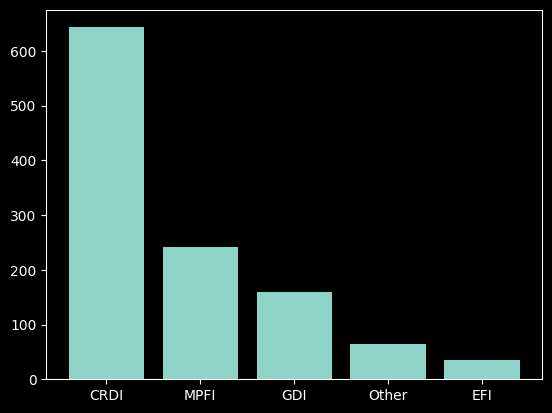

In [233]:
plt.bar(df['Fuel Supply System'].value_counts().index, df['Fuel Supply System'].value_counts().values)
plt.show()

In [234]:
df, dropped_fuel_sys = one_hot_encode_with_info(df, "Fuel Supply System", "FuelSys")


Feature: Fuel Supply System
All Categories: ['CRDI', 'EFI', 'GDI', 'MPFI', 'Other']
Dropped Category: CRDI


5. Fuel Type

In [235]:
# Drop all the row with 'Fuel Type' == 'Electric'
df = df[df['Fuel Type'] != 'Electric']

df, dropped_fuel_type = one_hot_encode_with_info(df, "Fuel Type", "Fuel")


Feature: Fuel Type
All Categories: ['CNG', 'Diesel', 'Petrol']
Dropped Category: CNG


6. 'Engine Type'

In [236]:
def clean_engine_type(value):
    if pd.isna(value):
        return 'Unknown'
    
    value = str(value).strip()
    
    # Kappa variants
    if 'Kappa' in value or 'kappa' in value:
        return 'Kappa'
    
    # K-Series variants
    if any(x in value for x in ['K10B', 'K10C', 'K12M', 'K12N', 'K14B', 'K15B', 'K15C', 'K Series', 'K series', 'k-series', 'Advanced K']):
        return 'K Series'
    
    # i-VTEC variants (Honda Petrol)
    if any(x in value for x in ['i-VTEC', 'i VTEC', 'iVTEC', '1.2L i-VTEC', '1.2 i-VTEC']):
        return 'i-VTEC'
    
    # i-DTEC variants (Honda Diesel)
    if any(x in value for x in ['i-DTEC', 'i DTEC']):
        return 'i-DTEC'
    
    # Revotron variants (Tata Petrol)
    if any(x in value for x in ['Revotron', 'REVOTRON']):
        return 'Revotron'
    
    # Revotorq variants (Tata Diesel)
    if any(x in value for x in ['Revotorq', 'REVOTORQ']):
        return 'Revotorq'
    
    # DDiS variants (Maruti Diesel)
    if any(x in value for x in ['DDiS', 'DDIS']):
        return 'DDiS'
    
    # IRDE2 variants (Bajaj)
    if 'IRDE2' in value:
        return 'IRDE2'
    
    # TSI variants (Volkswagen Petrol)
    if 'TSI' in value:
        return 'TSI'
    
    # TDI/TDCi/TDCI variants (Diesel)
    if any(x in value for x in ['TDI', 'TDCi', 'TDCI']):
        return 'TDI'
    
    # CRDi/CRDI variants (Hyundai/Kia Diesel)
    if any(x in value for x in ['CRDi', 'CRDI', 'CRDe']):
        return 'CRDi'
    
    # mHawk variants (Mahindra Diesel)
    if any(x in value for x in ['mHawk', 'mHAWk']):
        return 'mHawk'
    
    # mStallion variants (Mahindra Petrol)
    if 'mStallion' in value:
        return 'mStallion'
    
    # Kryotec variants (Tata)
    if any(x in value for x in ['Kryotec', 'KRYOJET']):
        return 'Kryotec'
    
    # SmartStream variants (Hyundai)
    if any(x in value for x in ['SmartStream', 'SMARTSTREAM', 'Smartstream']):
        return 'SmartStream'
    
    # F8D variants (Maruti)
    if 'F8D' in value:
        return 'F8D'
    
    # VVT variants
    if any(x in value for x in ['VVT', 'VTVT', 'VVTi', 'Ti-VCT']):
        return 'VVT'
    
    # TwinPower (BMW)
    if 'TwinPower' in value:
        return 'TwinPower'
    
    # D-4D variants (Toyota Diesel)
    if any(x in value for x in ['D-4D', '2KD-FTV', '2-GD FTV']):
        return 'Toyota Diesel'
    
    # Generic Petrol
    if 'Petrol' in value or 'petrol' in value:
        return 'Petrol'
    
    # Generic Diesel
    if 'Diesel' in value or 'diesel' in value:
        return 'Diesel'
    
    # In-Line
    if 'In-Line' in value or 'In Line' in value or 'Inline' in value:
        return 'In-Line'
    
    return 'Other'


# Apply
df['Engine Type'] = df['Engine Type'].apply(clean_engine_type)

In [237]:
df['Engine Type'].value_counts()

Engine Type
Petrol           166
Other            164
Diesel           146
In-Line           91
K Series          84
CRDi              64
VVT               56
TSI               54
i-VTEC            47
Revotron          46
Kappa             45
SmartStream       31
TDI               28
DDiS              23
mHawk             21
TwinPower         13
Toyota Diesel     12
i-DTEC            11
Kryotec            9
mStallion          9
Revotorq           8
F8D                4
IRDE2              2
Name: count, dtype: int64

In [238]:
df, dropped_engine_type = one_hot_encode_with_info(
    df,
    "Engine Type",
    "EngineType"
)


Feature: Engine Type
All Categories: ['CRDi', 'DDiS', 'Diesel', 'F8D', 'IRDE2', 'In-Line', 'K Series', 'Kappa', 'Kryotec', 'Other', 'Petrol', 'Revotorq', 'Revotron', 'SmartStream', 'TDI', 'TSI', 'Toyota Diesel', 'TwinPower', 'VVT', 'i-DTEC', 'i-VTEC', 'mHawk', 'mStallion']
Dropped Category: CRDi


7. 'Emission Norm Compliance'

In [239]:
def clean_emission_norm(x):

    if pd.isna(x):
        return None

    x = str(x).strip().lower()

    if "bs vi" in x or "bsvi" in x:
        return "BS6"

    elif "bs iv" in x or "bsiv" in x or "bharat stage iv" in x:
        return "BS4"

    elif "bs iii" in x or "bharat stage iii" in x:
        return "BS3"

    elif "euro" in x:
        return "EURO"

    else:
        return "Other"


df["Emission Norm Compliance"] = df["Emission Norm Compliance"].apply(clean_emission_norm)

In [240]:
df, dropped_emission_norm = one_hot_encode_with_info(df, "Emission Norm Compliance", "EmissionNorm")


Feature: Emission Norm Compliance
All Categories: ['BS3', 'BS4', 'BS6', 'EURO', 'Other']
Dropped Category: BS3


9. 'Drive Type'

In [241]:
def clean_drive_type(value):
    value = str(value).strip().upper().replace(' ', '')
    
    fwd_variants = ['FWD', '2WD', '4X2', 'FRONTWHEELDRIVE', 'TWOWHEELDRIVE', 'TWOWHHEELDRIVE', 'TWOWHHHEELDRIVE']
    rwd_variants = ['RWD', 'RWD(WITHMTT)']
    awd_variants = ['AWD', '4WD', '4X4']
    
    if value in fwd_variants:
        return 'FWD'
    elif value in rwd_variants:
        return 'RWD'
    elif value in awd_variants:
        return 'AWD'
    else:
        return 'FWD'

# Apply
df['Drive Type'] = df['Drive Type'].apply(clean_drive_type)

In [242]:
df, droped_drive_type = one_hot_encode_with_info(df, "Drive Type", "DriveType")


Feature: Drive Type
All Categories: ['AWD', 'FWD', 'RWD']
Dropped Category: AWD


10. 'Transmission'

In [243]:
transmission_map = {
    "Automatic": 1,
    "Manual": 0 
}

df['Transmission'] = df['Transmission'].map(transmission_map)

11. Power

In [244]:
df['Power'].head()

0    187.74 bhp
1    113.43 bhp
2    101.64 bhp
3    101.64 bhp
4    167.62 bhp
Name: Power, dtype: object

In [245]:
df['Power'] = df['Power'].str.replace(' bhp', '', regex=False).astype(float)


11. 'Valve Configuration'

In [246]:
def clean_valve_config(value):
    value = str(value).strip().upper()
    
    if 'DOHC' in value:
        return 'DOHC'
    elif 'SOHC' in value:
        return 'SOHC'
    else:
        return value

df['Valve Configuration'] = df['Valve Configuration'].apply(clean_valve_config)
print(df['Valve Configuration'].value_counts())

Valve Configuration
DOHC    1036
SOHC      96
IDSI       2
Name: count, dtype: int64


In [247]:
df, dropped_valve_config = one_hot_encode_with_info(df, "Valve Configuration", "ValveConfig")


Feature: Valve Configuration
All Categories: ['DOHC', 'IDSI', 'SOHC']
Dropped Category: DOHC


'engine_density'

In [248]:
df['Engine Density'] = df['Engine'] / df['No. of Cylinders']

df['Engine Density'].head()

0    496.00
1    338.25
2    365.50
3    365.50
4    489.00
Name: Engine Density, dtype: float64

In [249]:
bool_cols = df.select_dtypes(include='bool').columns.tolist()
df[bool_cols] = df[bool_cols].astype(int)

In [250]:
df.columns

Index(['Engine', 'No. of Cylinders', 'Valves Per Cylinder', 'Transmission',
       'Power', 'FuelSys_EFI', 'FuelSys_GDI', 'FuelSys_MPFI', 'FuelSys_Other',
       'Fuel_Diesel', 'Fuel_Petrol', 'EngineType_DDiS', 'EngineType_Diesel',
       'EngineType_F8D', 'EngineType_IRDE2', 'EngineType_In-Line',
       'EngineType_K Series', 'EngineType_Kappa', 'EngineType_Kryotec',
       'EngineType_Other', 'EngineType_Petrol', 'EngineType_Revotorq',
       'EngineType_Revotron', 'EngineType_SmartStream', 'EngineType_TDI',
       'EngineType_TSI', 'EngineType_Toyota Diesel', 'EngineType_TwinPower',
       'EngineType_VVT', 'EngineType_i-DTEC', 'EngineType_i-VTEC',
       'EngineType_mHawk', 'EngineType_mStallion', 'EmissionNorm_BS4',
       'EmissionNorm_BS6', 'EmissionNorm_EURO', 'EmissionNorm_Other',
       'DriveType_FWD', 'DriveType_RWD', 'ValveConfig_IDSI',
       'ValveConfig_SOHC', 'Engine Density'],
      dtype='object')

---

In [251]:
from sklearn.model_selection import train_test_split, GridSearchCV 
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV

In [252]:
# Features and target
X = df.drop(columns=['Power'])
y = df['Power']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [254]:
param_grid = {
    'n_estimators'    : [100, 200, 300],
    'max_depth'       : [8, 12, 16],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 5],
    'max_features'    : [0.6, 0.75, 0.85],
}

rf = RandomForestRegressor(
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,           
    verbose=2            
)

# # grid_search.fit(X_train, y_train)

# print("Best parameters:", grid_search.best_params_)
# print("Best CV R²:", round(grid_search.best_score_, 4))

In [255]:
total = len(X_train)

batch_sizes = sorted(set([
    int(total * 0.40),
    int(total * 0.50),
    int(total * 0.60),
    int(total * 0.70),
    int(total * 0.80),
    int(total * 0.90),
    total
]))

train_scores, val_scores, actual_sizes = [], [], []

for size in batch_sizes:
    size = min(size, len(X_train))   

    X_batch = X_train.iloc[:size]
    y_batch = y_train.iloc[:size]

    model =   RandomForestRegressor(
                n_estimators=500,
                max_depth=8,
                min_samples_split=10,
                min_samples_leaf=5,
                max_features=0.5,
                max_samples=0.7,
                bootstrap=True,
                random_state=42,
                n_jobs=-1
            )
    
    model.fit(X_batch, y_batch)

    train_r2 = r2_score(y_batch, model.predict(X_batch))
    val_r2   = r2_score(y_test,  model.predict(X_test))

    train_scores.append(round(train_r2, 4))
    val_scores.append(round(val_r2, 4))
    actual_sizes.append(size)

    print(f"Rows: {size:>5} | Train R²: {train_r2:.4f} | Val R²: {val_r2:.4f}")
 

Rows:   362 | Train R²: 0.7571 | Val R²: 0.7437
Rows:   453 | Train R²: 0.7847 | Val R²: 0.7458
Rows:   544 | Train R²: 0.7826 | Val R²: 0.7451
Rows:   634 | Train R²: 0.7947 | Val R²: 0.7472
Rows:   725 | Train R²: 0.8109 | Val R²: 0.7405
Rows:   816 | Train R²: 0.8124 | Val R²: 0.7417
Rows:   907 | Train R²: 0.8266 | Val R²: 0.7500


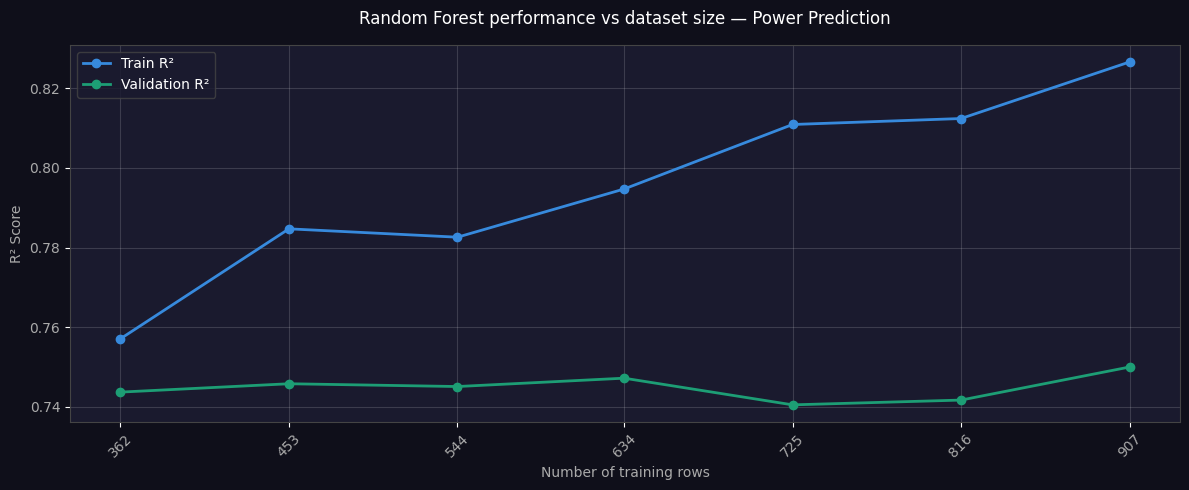

In [256]:
plt.style.use('dark_background')

plt.figure(figsize=(12, 5))
plt.plot(actual_sizes, train_scores, label='Train R²', marker='o', color='#378ADD', linewidth=2)
plt.plot(actual_sizes, val_scores,   label='Validation R²', marker='o', color='#1D9E75', linewidth=2)

plt.xlabel("Number of training rows", color='#aaaaaa')
plt.ylabel("R² Score", color='#aaaaaa')
plt.title("Random Forest performance vs dataset size — Power Prediction", color='white', pad=15)

plt.xticks(actual_sizes, rotation=45, color='#aaaaaa')
plt.yticks(color='#aaaaaa')

plt.gca().set_facecolor('#1a1a2e')
plt.gcf().set_facecolor('#0f0f1a')

plt.gca().spines['bottom'].set_color('#444444')
plt.gca().spines['left'].set_color('#444444')
plt.gca().spines['top'].set_color('#444444')
plt.gca().spines['right'].set_color('#444444')

plt.legend(facecolor='#1a1a2e', edgecolor='#444444', labelcolor='white')
plt.grid(True, alpha=0.15, color='#ffffff')
plt.tight_layout()
plt.show()

In [ ]:
print(X_train.columns.tolist())

['Engine', 'No. of Cylinders', 'Valves Per Cylinder', 'Kerb Weight', 'Transmission', 'Valve Configuration_was_missing', 'Fuel Supply System_was_missing', 'Kerb Weight_was_missing', 'Drive Type_was_missing', 'FuelSys_EFI', 'FuelSys_GDI', 'FuelSys_MPFI', 'FuelSys_Other', 'Fuel_Diesel', 'Fuel_Petrol', 'EngineType_DDiS', 'EngineType_Diesel', 'EngineType_F8D', 'EngineType_IRDE2', 'EngineType_In-Line', 'EngineType_K Series', 'EngineType_Kappa', 'EngineType_Kryotec', 'EngineType_Other', 'EngineType_Petrol', 'EngineType_Revotorq', 'EngineType_Revotron', 'EngineType_SmartStream', 'EngineType_TDI', 'EngineType_TSI', 'EngineType_Toyota Diesel', 'EngineType_TwinPower', 'EngineType_VVT', 'EngineType_i-DTEC', 'EngineType_i-VTEC', 'EngineType_mHawk', 'EngineType_mStallion', 'EmissionNorm_BS4', 'EmissionNorm_BS6', 'EmissionNorm_EURO', 'EmissionNorm_Other', 'DriveType_FWD', 'DriveType_RWD', 'ValveConfig_IDSI', 'ValveConfig_SOHC', 'Engine Density']


In [ ]:
# import os
# import joblib
# os.makedirs("model", exist_ok=True)
# joblib.dump(best_model, "model/power_model.pkl")
# print("Model saved!")

Model saved!


> In the next step we will be testing the model performance with different size of data